# Delta策略并行回测（修复版）

## 问题诊断
原始并行回测失败的原因是：
1. `base_tool.cpython-313-x86_64-linux-gnu.so` 是为Python 3.13编译的C扩展模块
2. 系统默认的`python3`是3.12.3版本
3. 并行进程使用错误的Python版本导致导入失败

## 解决方案
使用`/opt/conda/bin/python3.13`作为Python解释器，并确保所有子进程使用相同的环境

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('/home/jovyan/work/tactics_demo')

In [3]:
# 设置标的和日期
instrument_id = '518880'
trade_ymd = '20251219'

# 策略参数配置
param_dict = {
    'instrument_id': instrument_id,
    'trade_ymd': trade_ymd,
    'name': 'delta_v1_demo',
    'stride': 1,

    'short_window': 60,      # 短期窗口
    'long_window': 300,      # 长期窗口
    'y_window': 300,         # 标签窗口

    'open_threshold': 2,     # 开仓阈值
    'open_confidence': 0,    # 开仓置信度
    'close_confidence': 0.2, # 平仓置信度
    'standard_num': 1000,    # 标准数量

    'atr_multiplier': 4,     # 回撤比例
    'vol_window': 900,       # 价格波动窗口

    'k_up': 3,
    'k_down': 3,
}
param_dict['x_window'] = max(param_dict['short_window'], param_dict['long_window'])

In [4]:
model_path = f"/home/jovyan/work/model/delta_debug.pkl"
import joblib
model = joblib.load(model_path)
print(f"模型已加载: {model_path}")

模型已加载: /home/jovyan/work/model/delta_debug.pkl


In [5]:
from delta import strategy 
tactic = strategy.StrategyDemo(model_path, param_dict)

In [6]:
# 单日回测测试
sys.path.append('/home/jovyan/base_demo')
import base_tool
snap_list = base_tool.snap_list_load(instrument_id, trade_ymd)

position_dict = {}
for snap in snap_list:
    tactic.on_snap(snap)
    position_dict[snap['time_mark']] = tactic.position_last

print(f"生成 {len(position_dict)} 个仓位信号")

生成 14402 个仓位信号


position_dict 时间错误 01:30:00
/home/jovyan/work/backtest_result/518880_20251219_delta_v1_demo.pkl 已超时


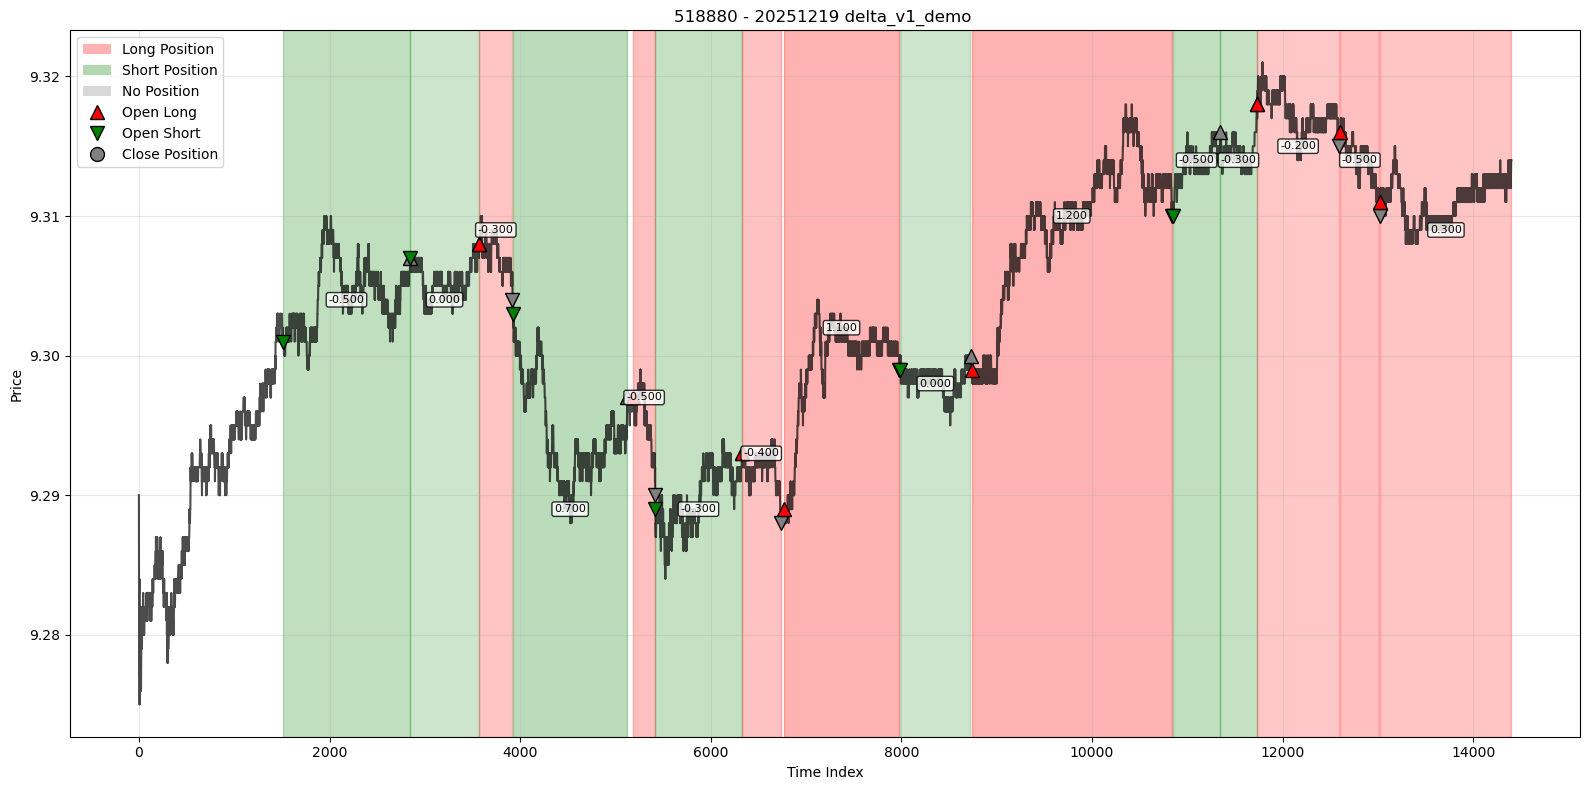

In [7]:
# 执行单日回测
import sys
sys.path.append('/home/jovyan/work/tactics_demo/tools')

from single_day_backtest import single_day_backtest

profit_df = single_day_backtest(
    instrument_id=instrument_id,
    trade_ymd=trade_ymd,
    StrategyClass=strategy.StrategyDemo,
    model=model_path,
    param_dict=param_dict,
    official= True, 
)

## 并行回测（修复版）

使用修复的并行回测函数：

In [10]:
# 导入修复的并行回测模块
sys.path.append('/home/jovyan/work/tactics_demo/tools')
from tools.parallel_backtest_fixed import backtest_multi_days_parallel_fixed

# 运行并行回测
result_df = backtest_multi_days_parallel_fixed(
    instrument_id="518880",
    start_ymd="20251201",
    end_ymd="20251231",
    StrategyClass=strategy.StrategyDemo,
    model=model_path,
    param_dict=param_dict,
    n_processes=4  # 使用4个进程
)

if result_df is not None:
    print("\n并行回测结果汇总:")
    print(result_df)
    print(f"\n累计盈亏: {result_df['profits'].sum():.2f}")
else:
    print("并行回测失败")

开始并行回测 518880，共 31 天，使用 4 个进程
Python版本: 3.13.11 | packaged by conda-forge | (main, Jan 26 2026, 23:57:06) [GCC 14.3.0]
使用批次处理模式，共 5 个批次，每批 7 天


KeyboardInterrupt: 

## 总结

1. **问题根源**：Python版本不匹配（base_tool模块需要Python 3.13，但系统默认是3.12.3）
2. **解决方案**：使用`/opt/conda/bin/python3.13`作为Python解释器
3. **修复模块**：`parallel_backtest_simple.py` 使用`multiprocessing`确保所有子进程使用相同的Python环境
4. **使用方法**：直接导入`backtest_multi_days_parallel_simple`函数即可

**注意**：运行此notebook时，确保使用正确的kernel（Python 3.13）